In [1]:
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# ==========================================
# target mode
# ==========================================
# 想尽量贴论文，这里必须用 sparam
TARGET_MODE = "sparam"
HALF_CIRCUIT_RATIO = 0.25
SUBSET_RANDOM_SEED = 42


In [3]:
# ==========================================
# 路径与尺寸
# ==========================================
MATRIX_DIR = Path("./Auged_diag_dataset_pack_full")
TARGET_DIR = Path("./Auged_diag_dataset_pack_120")

N_ROWS = 16
N_COLS = 16

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 128

In [4]:
def load_rf_pack(matrix_dir, target_dir, target_mode):
    matrix_dir = Path(matrix_dir)
    target_dir = Path(target_dir)

    matrix = np.load(matrix_dir / "matrix.npy")   # [N,1,H,W]
    freq = np.load(target_dir / "freq.npy")       # [Nf]

    if target_mode == "sparam":
        target = np.load(target_dir / "sparam.npy")   # [N,4,Nf]
    elif target_mode == "mag":
        target = np.load(target_dir / "mag.npy")      # [N,2,Nf]
    elif target_mode == "db":
        target = np.load(target_dir / "db.npy")       # [N,2,Nf]
    else:
        raise ValueError("Unknown TARGET_MODE")

    if len(matrix) != len(target):
        raise ValueError(f"matrix样本数 {len(matrix)} != target样本数 {len(target)}")

    return {
        "matrix": matrix,
        "freq": freq,
        "target": target,
        "n_samples": len(matrix),
        "n_freq": target.shape[-1],
    }

In [5]:
def normalize_freq_to_minus1_1(freq):
    freq = freq.astype(np.float32)
    fmin = float(freq.min())
    fmax = float(freq.max())
    freq_norm = 2.0 * (freq - fmin) / (fmax - fmin) - 1.0
    return freq_norm.astype(np.float32), fmin, fmax

In [6]:
class RFFreqDataset(Dataset):
    """
    全频段并行 + 离散索引查表：
    一次性返回结构的所有频率点索引，极大提升训练速度。
    """
    def __init__(self, matrix, target, circuit_indices, freq_norm):
        self.matrix = matrix
        self.target = target
        self.circuit_indices = np.asarray(circuit_indices, dtype=np.int64)

        self.n_circuits = len(self.circuit_indices)
        self.n_freq = target.shape[-1]
        
        # 预先生成 0 ~ Nf-1 的整数索引
        self.freq_indices = np.arange(self.n_freq, dtype=np.int64)

    def __len__(self):
        # 长度恢复为拓扑结构的数量
        return self.n_circuits

    def __getitem__(self, idx):
        real_circuit_idx = self.circuit_indices[idx]

        matrix_one = self.matrix[real_circuit_idx]               # [1, H, W]
        target_all = self.target[real_circuit_idx]               # [4, Nf]

        return {
            "matrix": torch.as_tensor(matrix_one, dtype=torch.float32),
            # 返回整数索引，并指定类型为 long，供 Embedding 使用
            "freq_index": torch.as_tensor(self.freq_indices, dtype=torch.long),
            "target": torch.as_tensor(target_all, dtype=torch.float32),
            "sample_index": int(real_circuit_idx),
        }

In [7]:
class FrequencyEmbedding(nn.Module):
    def __init__(self, num_freqs=120, embed_dim=64):
        super().__init__()
        # 使用极其稳定的离散查表法，字典大小为120，映射到64维
        self.embed = nn.Embedding(num_freqs, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, embed_dim),
        )

    def forward(self, freq_idx):
        # freq_idx 的形状现在是 [B, Nf]
        x = self.embed(freq_idx)       # 出来自动变成 [B, Nf, 64]
        x = self.norm(x)
        x = self.mlp(x)                # [B, Nf, 64]
        return x

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.GroupNorm(num_groups=8, num_channels=out_channels)
        
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.GroupNorm(num_groups=8, num_channels=out_channels)

        # shortcut
        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.GroupNorm(num_groups=8, num_channels=out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

In [9]:
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, base_channels=64, out_dim=256):
        super().__init__()

        # stem
        self.stem = nn.Sequential(
            nn.Conv2d(1, base_channels, 3, 1, 1, bias=False),
            nn.GroupNorm(num_groups=8, num_channels=base_channels),
            nn.ReLU(inplace=True),
        )

        # stages（类似 ResNet18 但更轻）
        self.layer1 = nn.Sequential(
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
            ResidualBlock(base_channels, base_channels),
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(base_channels, base_channels * 2, stride=2),
            ResidualBlock(base_channels * 2, base_channels * 2),
            ResidualBlock(base_channels * 2, base_channels * 2),
        )

        self.layer3 = nn.Sequential(
            ResidualBlock(base_channels * 2, out_dim, stride=2),
            ResidualBlock(out_dim, out_dim),
            ResidualBlock(out_dim, out_dim),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

    def forward(self, x):
        x = self.stem(x)       # [B,64,16,16]
        x = self.layer1(x)     # [B,64,16,16]
        x = self.layer2(x)     # [B,128,8,8]
        x = self.layer3(x)     # [B,256,4,4]
        x = self.pool(x)       # [B,256,1,1]
        x = x.flatten(1)       # [B,256]
        return x

In [10]:
class ResNetFreqSurrogate(nn.Module):
    def __init__(
        self,
        freq_dim=64,
        structure_dim=256,
        hidden_dim=512,
        dropout=0.3,
        num_freqs=120,
    ):
        super().__init__()

        self.feature_extractor = ResNetFeatureExtractor(
            base_channels=64,
            out_dim=structure_dim,
        )

        self.freq_embed = FrequencyEmbedding(num_freqs=num_freqs, embed_dim=freq_dim)

        self.head = nn.Sequential(
            nn.Linear(structure_dim + freq_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, 128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 4),
        )

        self.out_act = nn.Tanh()

    def forward(self, matrix, freq):
        struct_feat = self.feature_extractor(matrix)   # [B,256]
        freq_feat = self.freq_embed(freq)              # [B,Nf,64]

        B, Nf, Df = freq_feat.shape
        Ds = struct_feat.shape[1]

        struct_feat = struct_feat.unsqueeze(1).expand(B, Nf, Ds)
        fusion = torch.cat([struct_feat, freq_feat], dim=-1)

        out = self.head(fusion)        # [B,Nf,4]
        out = self.out_act(out)

        return out.transpose(1, 2)

In [11]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_n = 0

    for batch in tqdm(loader, desc="Training"):
        matrices = batch["matrix"].to(DEVICE, non_blocking=True)
        # 获取整数频率索引，类型为 long
        freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
        targets = batch["target"].to(DEVICE, non_blocking=True)

        pred = model(matrices, freq_indices)
        loss = F.mse_loss(pred, targets)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        
        # 加上梯度裁剪，为 Transformer 系上安全带！
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        bs = matrices.shape[0]
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(total_n, 1)

In [12]:
@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    total_n = 0

    for batch in loader:
        matrices = batch["matrix"].to(DEVICE, non_blocking=True)
        freq_indices = batch["freq_index"].to(DEVICE, dtype=torch.long, non_blocking=True)
        targets = batch["target"].to(DEVICE, non_blocking=True)

        pred = model(matrices, freq_indices)
        loss = F.mse_loss(pred, targets)

        bs = matrices.shape[0]
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / max(total_n, 1)

In [13]:
@torch.no_grad()
def predict_full_curve(model, pack, sample_index):
    model.eval()

    matrix_one = pack["matrix"][sample_index:sample_index + 1].astype(np.float32)   # [1, 1, H, W]
    true_y = pack["target"][sample_index]                                            # [4, Nf]
    freq = pack["freq"]                                                              # [Nf]

    n_freq = len(freq)

    # 构建 [1, Nf] 形状的整数索引张量
    freq_indices = np.arange(n_freq, dtype=np.int64).reshape(1, -1)

    matrix_t = torch.from_numpy(matrix_one).to(DEVICE)
    freq_t = torch.from_numpy(freq_indices).to(DEVICE)

    # 模型输出形状是 [1, 4, Nf]，去掉 batch 维度变成 [4, Nf]
    pred = model(matrix_t, freq_t).squeeze(0).cpu().numpy()         

    result = {
        "freq": freq,
        "target_true": true_y,
        "target_pred": pred,
    }

    # (保留你原本计算 dB, Mag 和复数虚实部的后半段代码即可)
    s11_true = true_y[0] + 1j * true_y[1]
    s21_true = true_y[2] + 1j * true_y[3]
    s11_pred = pred[0] + 1j * pred[1]
    s21_pred = pred[2] + 1j * pred[3]

    result.update({
        "s11_true_real": np.real(s11_true),
        "s11_true_imag": np.imag(s11_true),
        "s21_true_real": np.real(s21_true),
        "s21_true_imag": np.imag(s21_true),

        "s11_pred_real": np.real(s11_pred),
        "s11_pred_imag": np.imag(s11_pred),
        "s21_pred_real": np.real(s21_pred),
        "s21_pred_imag": np.imag(s21_pred),

        "s11_true_mag": np.abs(s11_true),
        "s21_true_mag": np.abs(s21_true),
        "s11_pred_mag": np.abs(s11_pred),
        "s21_pred_mag": np.abs(s21_pred),

        "s11_true_db": 20 * np.log10(np.maximum(np.abs(s11_true), 1e-12)),
        "s21_true_db": 20 * np.log10(np.maximum(np.abs(s21_true), 1e-12)),
        "s11_pred_db": 20 * np.log10(np.maximum(np.abs(s11_pred), 1e-12)),
        "s21_pred_db": 20 * np.log10(np.maximum(np.abs(s21_pred), 1e-12)),
    })

    return result

In [14]:
def plot_training_curves(train_loss_history, val_loss_history, save_path=None):
    epochs = np.arange(1, len(train_loss_history) + 1)
    best_epoch = int(np.argmin(val_loss_history)) + 1
    best_val = float(np.min(val_loss_history))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss_history, label="Train Loss")
    plt.plot(epochs, val_loss_history, label="Validation Loss")
    plt.scatter([best_epoch], [best_val], label=f"Best Val @ {best_epoch}", zorder=5)

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"training curve saved to: {save_path}")

    plt.show()
    print(f"Best val loss = {best_val:.6f} at epoch {best_epoch}")

In [15]:
def plot_one_sample_prediction(model, pack, sample_index, title_prefix=""):
    result = predict_full_curve(
        model=model,
        pack=pack,
        sample_index=sample_index
    )

    freq = result["freq"] / 1e9
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))

    axes[0, 0].plot(freq, result["s11_true_real"], label="True Re(S11)")
    axes[0, 0].plot(freq, result["s11_true_imag"], label="True Im(S11)")
    axes[0, 0].plot(freq, result["s11_pred_real"], "--", label="Pred Re(S11)")
    axes[0, 0].plot(freq, result["s11_pred_imag"], "--", label="Pred Im(S11)")
    axes[0, 0].set_title(f"{title_prefix}idx={sample_index} - S11 Re/Im")
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    axes[0, 1].plot(freq, result["s21_true_real"], label="True Re(S21)")
    axes[0, 1].plot(freq, result["s21_true_imag"], label="True Im(S21)")
    axes[0, 1].plot(freq, result["s21_pred_real"], "--", label="Pred Re(S21)")
    axes[0, 1].plot(freq, result["s21_pred_imag"], "--", label="Pred Im(S21)")
    axes[0, 1].set_title(f"{title_prefix}idx={sample_index} - S21 Re/Im")
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    axes[1, 0].plot(freq, result["s11_true_mag"], label="True |S11|")
    axes[1, 0].plot(freq, result["s11_pred_mag"], "--", label="Pred |S11|")
    axes[1, 0].set_title(f"{title_prefix}idx={sample_index} - S11 Magnitude")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    axes[1, 1].plot(freq, result["s21_true_mag"], label="True |S21|")
    axes[1, 1].plot(freq, result["s21_pred_mag"], "--", label="Pred |S21|")
    axes[1, 1].set_title(f"{title_prefix}idx={sample_index} - S21 Magnitude")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    axes[2, 0].plot(freq, result["s11_true_db"], label="True S11 (dB)")
    axes[2, 0].plot(freq, result["s11_pred_db"], "--", label="Pred S11 (dB)")
    axes[2, 0].set_title(f"{title_prefix}idx={sample_index} - S11 dB")
    axes[2, 0].grid(True)
    axes[2, 0].legend()

    axes[2, 1].plot(freq, result["s21_true_db"], label="True S21 (dB)")
    axes[2, 1].plot(freq, result["s21_pred_db"], "--", label="Pred S21 (dB)")
    axes[2, 1].set_title(f"{title_prefix}idx={sample_index} - S21 dB")
    axes[2, 1].grid(True)
    axes[2, 1].legend()

    for ax in axes.ravel():
        ax.set_xlabel("Frequency (GHz)")

    plt.tight_layout()
    plt.show()

    mae_s11_db = np.mean(np.abs(result["s11_true_db"] - result["s11_pred_db"]))
    mae_s21_db = np.mean(np.abs(result["s21_true_db"] - result["s21_pred_db"]))
    print(f"sample_index = {sample_index}")
    print(f"MAE S11 (dB) = {mae_s11_db:.6f}")
    print(f"MAE S21 (dB) = {mae_s21_db:.6f}")
    print("-" * 60)

In [16]:
def plot_random_samples(model, pack, val_indices, train_indices, n_samples=5, seed=42, from_val=True):
    rng = random.Random(seed)
    pool = list(val_indices if from_val else train_indices)
    n_samples = min(n_samples, len(pool))
    chosen = rng.sample(pool, n_samples)
    print("chosen sample indices:", chosen)

    for idx in chosen:
        plot_one_sample_prediction(model, pack, idx)

In [17]:
pack = load_rf_pack(
    matrix_dir=MATRIX_DIR,
    target_dir=TARGET_DIR,
    target_mode=TARGET_MODE,
)

In [18]:
all_indices = np.arange(pack["n_samples"])

rng = np.random.default_rng(SUBSET_RANDOM_SEED)
n_subset = max(1, int(round(len(all_indices) * HALF_CIRCUIT_RATIO)))
subset_indices = np.sort(rng.choice(all_indices, size=n_subset, replace=False))

print(f"Using {len(subset_indices)} / {len(all_indices)} circuits "
      f"({len(subset_indices)/len(all_indices):.1%})")

Using 15000 / 60000 circuits (25.0%)


In [19]:
train_indices, val_indices = train_test_split(
    subset_indices,
    train_size=0.95,
    random_state=42,
    shuffle=True,
)

print(f"Train circuits: {len(train_indices)}")
print(f"Val circuits:   {len(val_indices)}")

Train circuits: 14250
Val circuits:   750


In [20]:
freq_norm, freq_min, freq_max = normalize_freq_to_minus1_1(pack["freq"])

In [21]:
train_set = RFFreqDataset(
    matrix=pack["matrix"],
    target=pack["target"],
    circuit_indices=train_indices,
    freq_norm=freq_norm,
)

val_set = RFFreqDataset(
    matrix=pack["matrix"],
    target=pack["target"],
    circuit_indices=val_indices,
    freq_norm=freq_norm,
)

In [22]:
train_loader = DataLoader(
    train_set,
    batch_size=512,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_set,
    batch_size=512,
    shuffle=False,
    num_workers=0,
)

In [23]:
model = ResNetFreqSurrogate(
    freq_dim=64,
    structure_dim=256,
    hidden_dim=512,
    dropout=0.3,
    num_freqs=pack["n_freq"],
).to(DEVICE)

In [24]:
def hybrid_lr_scheduler(epoch, total_epochs=EPOCHS, warmup_epochs=3):
    """
    根据图 3(a) 紫色曲线：
    - 起点并非 0，而是在大约 50% 峰值处，用 3 个 Epoch 升到最高点。
    - 之后是一个饱满的余弦衰减，直接平滑降到 Epoch 30 的接近 0 处。
    """
    if epoch <= warmup_epochs:
        # 预热期：从 0.5 倍峰值线性增加到 1.0 倍
        start_ratio = 0.5
        return start_ratio + (1.0 - start_ratio) * (float(epoch) / warmup_epochs)
    else:
        # 余弦退火：从 epoch 3 到 30，平滑下降到 0
        progress = float(epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
        # progress 从 0 变到 1，结果从 1.0 平滑降到 0.0
        return 0.5 * (1.0 + math.cos(math.pi * progress))

In [25]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3.5e-4, 
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=hybrid_lr_scheduler)

In [26]:
best_val = 1e9
best_path = "single_client_surrogate.pt"
train_loss_history = []
val_loss_history = []

In [27]:
def count_parameters(module):
    """计算传入模块的参数总量"""
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

# 确保模型已经实例化
# model = FrequencyQueryEMSurrogate().to(DEVICE)

print("=" * 50)
print("📊 ResNet 模型参数统计")
print("=" * 50)

print(f"1. ResNet Feature Extractor      : {count_parameters(model.feature_extractor):,}")
print(f"2. Frequency Embedding           : {count_parameters(model.freq_embed):,}")
print(f"3. Prediction Head               : {count_parameters(model.head):,}")

print("-" * 50)
print(f"✨ Total Parameters              : {count_parameters(model):,}")
print("=" * 50)

📊 ResNet 模型参数统计
1. ResNet Feature Extractor      : 4,324,032
2. Frequency Embedding           : 24,384
3. Prediction Head               : 329,092
--------------------------------------------------
✨ Total Parameters              : 4,677,508


In [28]:
import time
start_time = time.time()
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = eval_one_epoch(model, val_loader)
    scheduler.step()

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:03d} | lr {lr_now:.6e} | train {train_loss:.6f} | val {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            "model": model.state_dict(),
            "train_loss_history": train_loss_history,
            "val_loss_history": val_loss_history,
        }, best_path)
end_time = time.time()

print(end_time - start_time)

Training: 100%|██████████| 28/28 [00:01<00:00, 17.82it/s]


Epoch 000 | lr 2.333333e-04 | train 0.175821 | val 0.163836


Training: 100%|██████████| 28/28 [00:01<00:00, 22.47it/s]


Epoch 001 | lr 2.916667e-04 | train 0.165017 | val 0.155076


Training: 100%|██████████| 28/28 [00:01<00:00, 24.79it/s]


...

Epoch 125 | lr 2.210326e-07 | train 0.006809 | val 0.017807


Training: 100%|██████████| 28/28 [00:01<00:00, 25.02it/s]


Epoch 126 | lr 5.526688e-08 | train 0.006802 | val 0.017804


Training: 100%|██████████| 28/28 [00:01<00:00, 25.05it/s]

Epoch 127 | lr 0.000000e+00 | train 0.006810 | val 0.017803
148.579030752182


In [29]:
print("best val =", best_val)
print("saved to", best_path)


best val = 0.017697072347005207
saved to single_client_surrogate.pt


In [30]:
torch.save({
    "model": model.state_dict(),
    "train_loss_history": train_loss_history,
    "val_loss_history": val_loss_history,
}, "last_cnn_surrogate.pt")

training curve saved to: training_curve_cnn.png


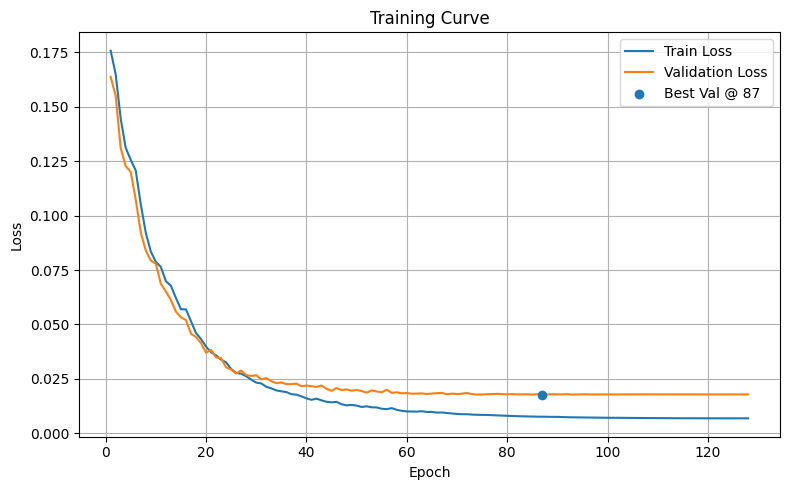

Best val loss = 0.017697 at epoch 87


In [31]:
plot_training_curves(
    train_loss_history,
    val_loss_history,
    save_path="training_curve_cnn.png"
)

In [32]:
ckpt = torch.load(best_path, map_location=DEVICE)

model = ResNetFreqSurrogate(
    freq_dim=64,
    structure_dim=256,
    hidden_dim=512,
    dropout=0.3,
    num_freqs=pack["n_freq"],
).to(DEVICE)

model.load_state_dict(ckpt["model"])
model.eval()

print("model loaded.")

model loaded.


chosen sample indices: [np.int64(14443), np.int64(6788), np.int64(7153), np.int64(48049), np.int64(32734)]


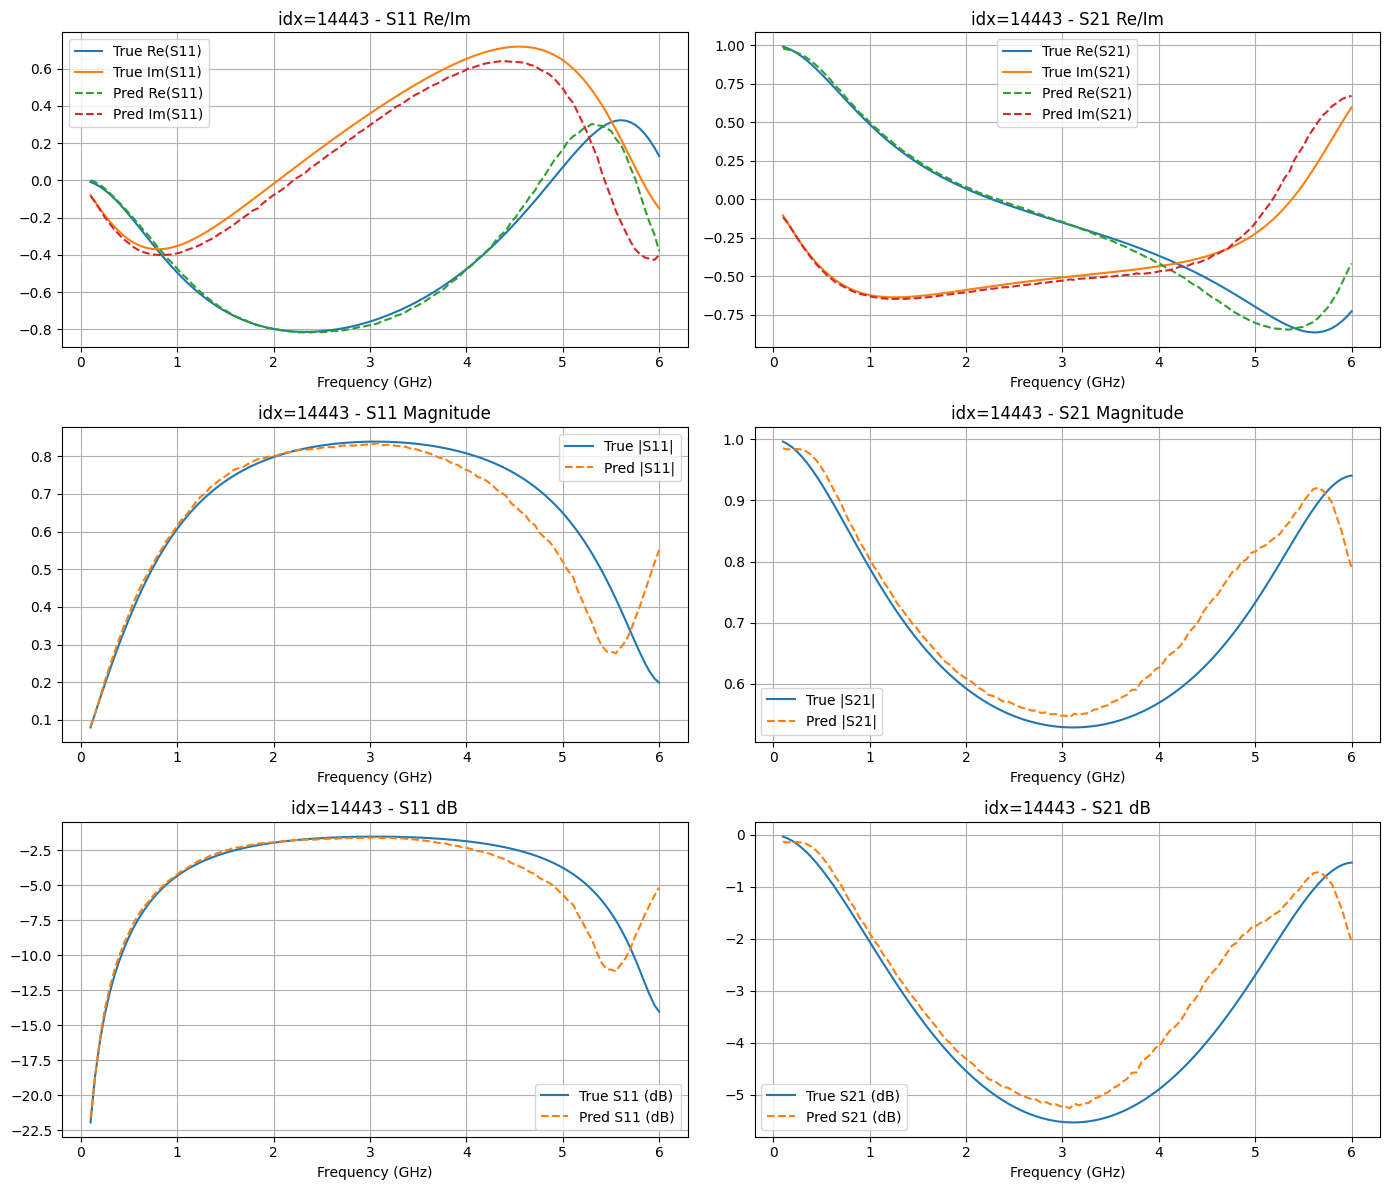

sample_index = 14443
MAE S11 (dB) = 0.915014
MAE S21 (dB) = 0.472419
------------------------------------------------------------


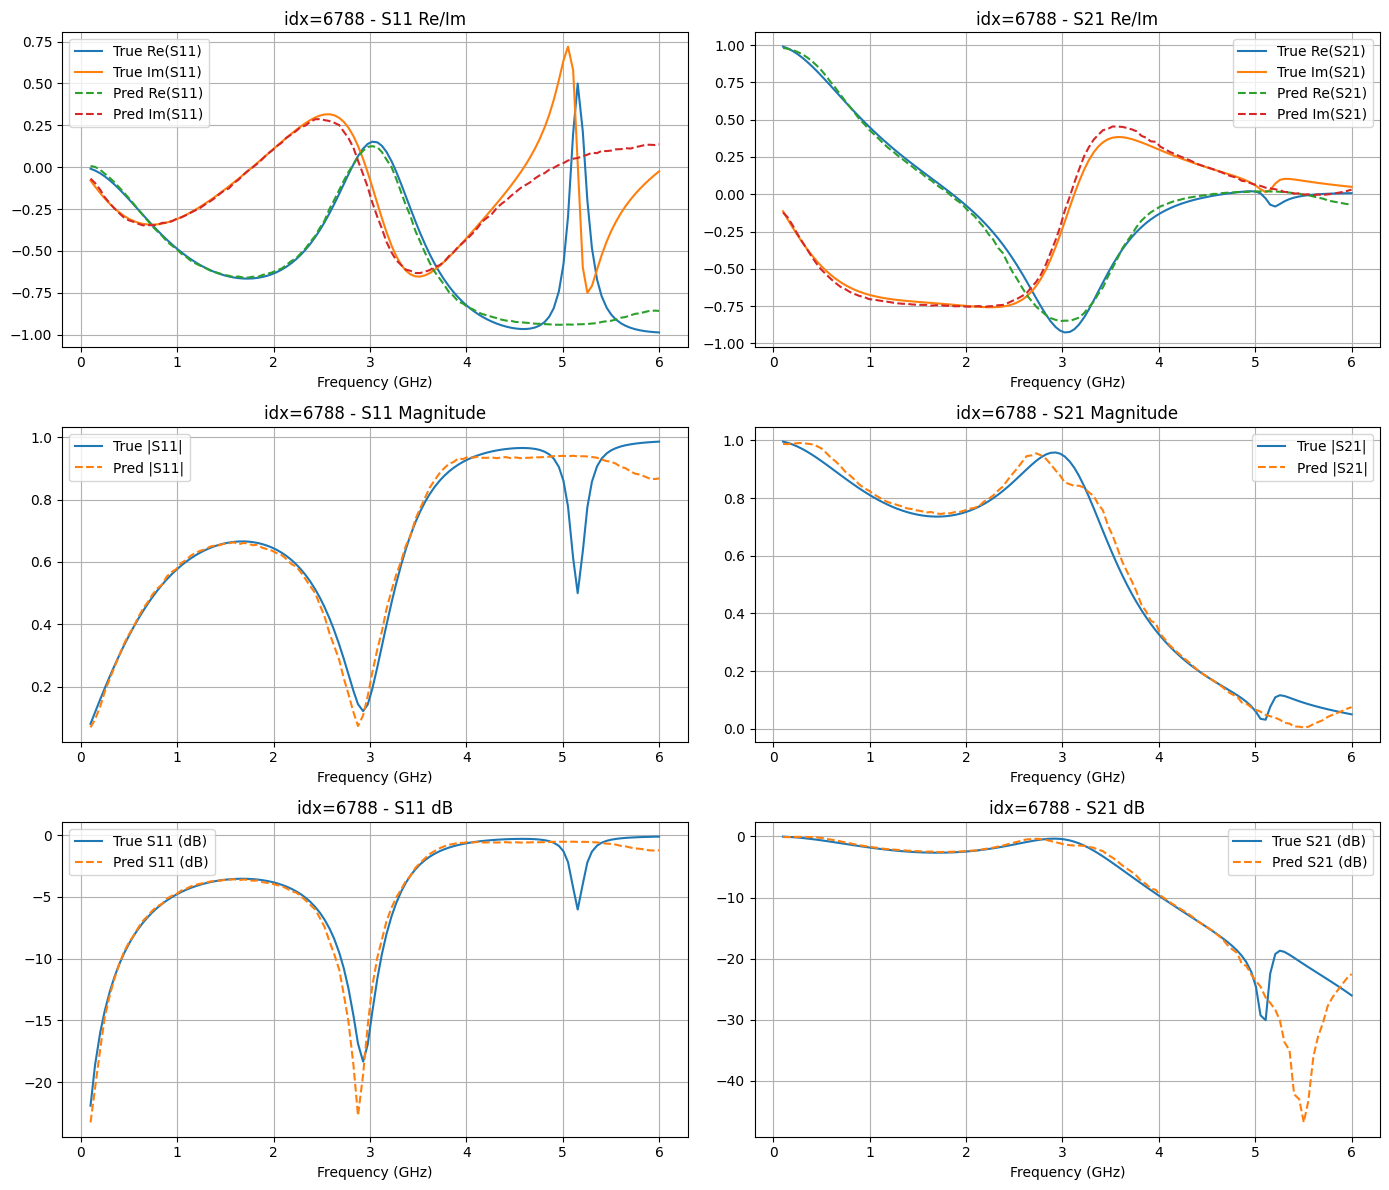

sample_index = 6788
MAE S11 (dB) = 0.599779
MAE S21 (dB) = 1.940078
------------------------------------------------------------


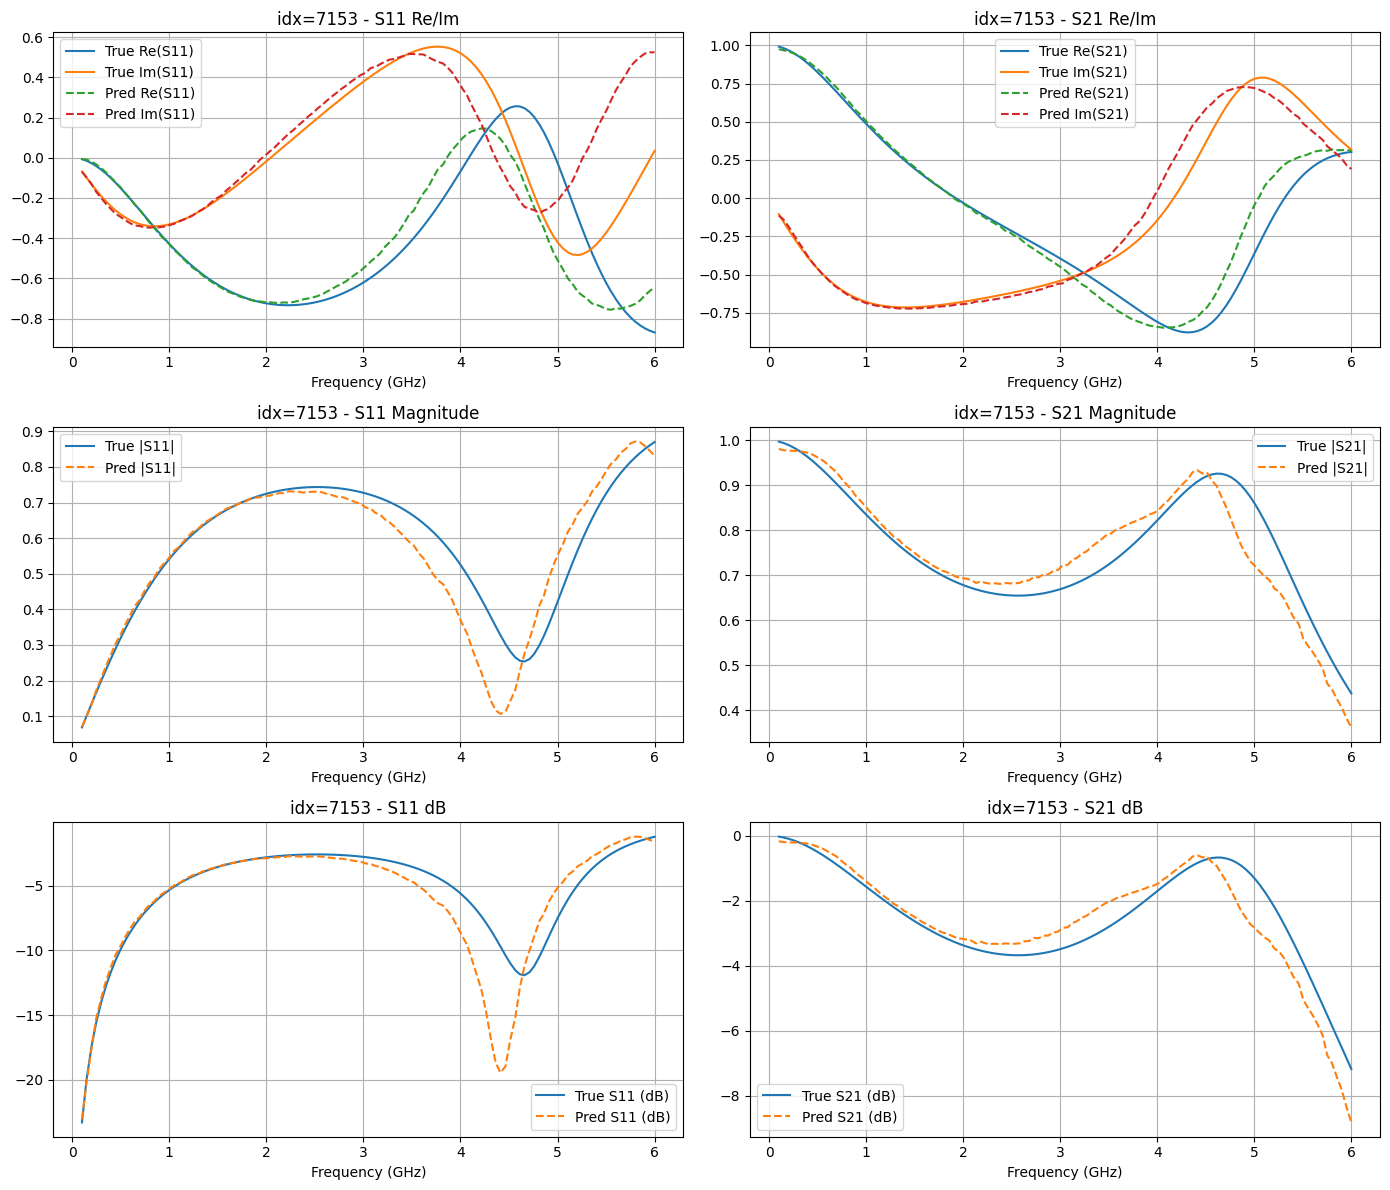

sample_index = 7153
MAE S11 (dB) = 1.210746
MAE S21 (dB) = 0.508778
------------------------------------------------------------


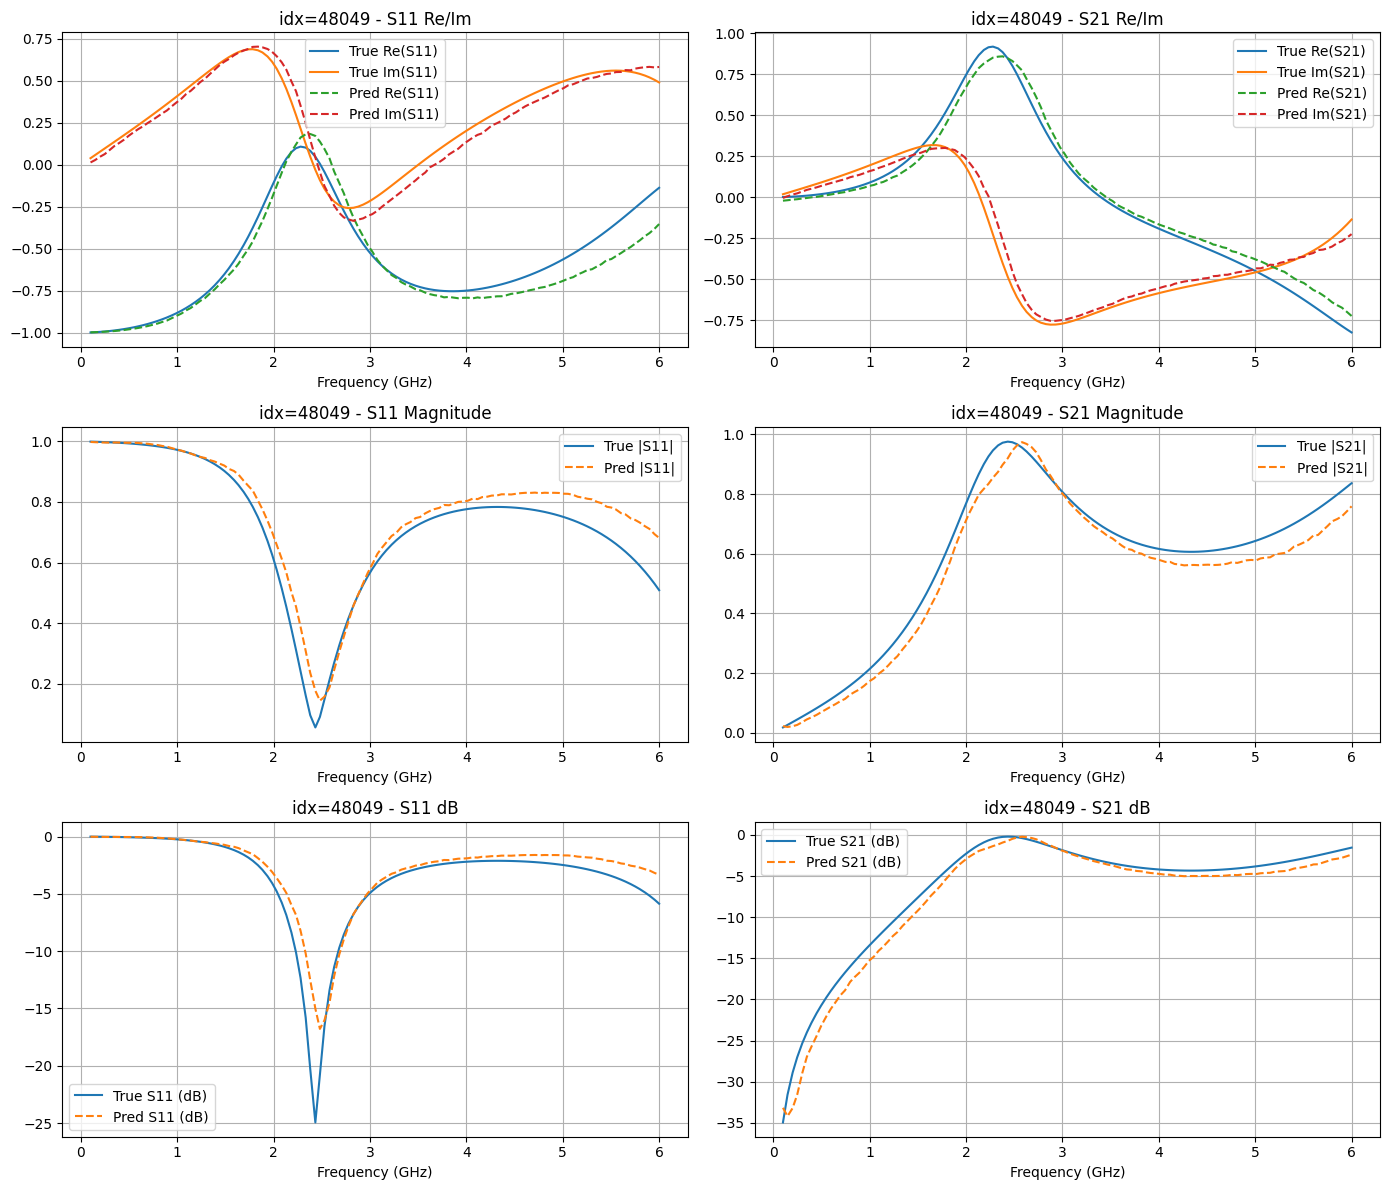

sample_index = 48049
MAE S11 (dB) = 0.821452
MAE S21 (dB) = 1.048806
------------------------------------------------------------


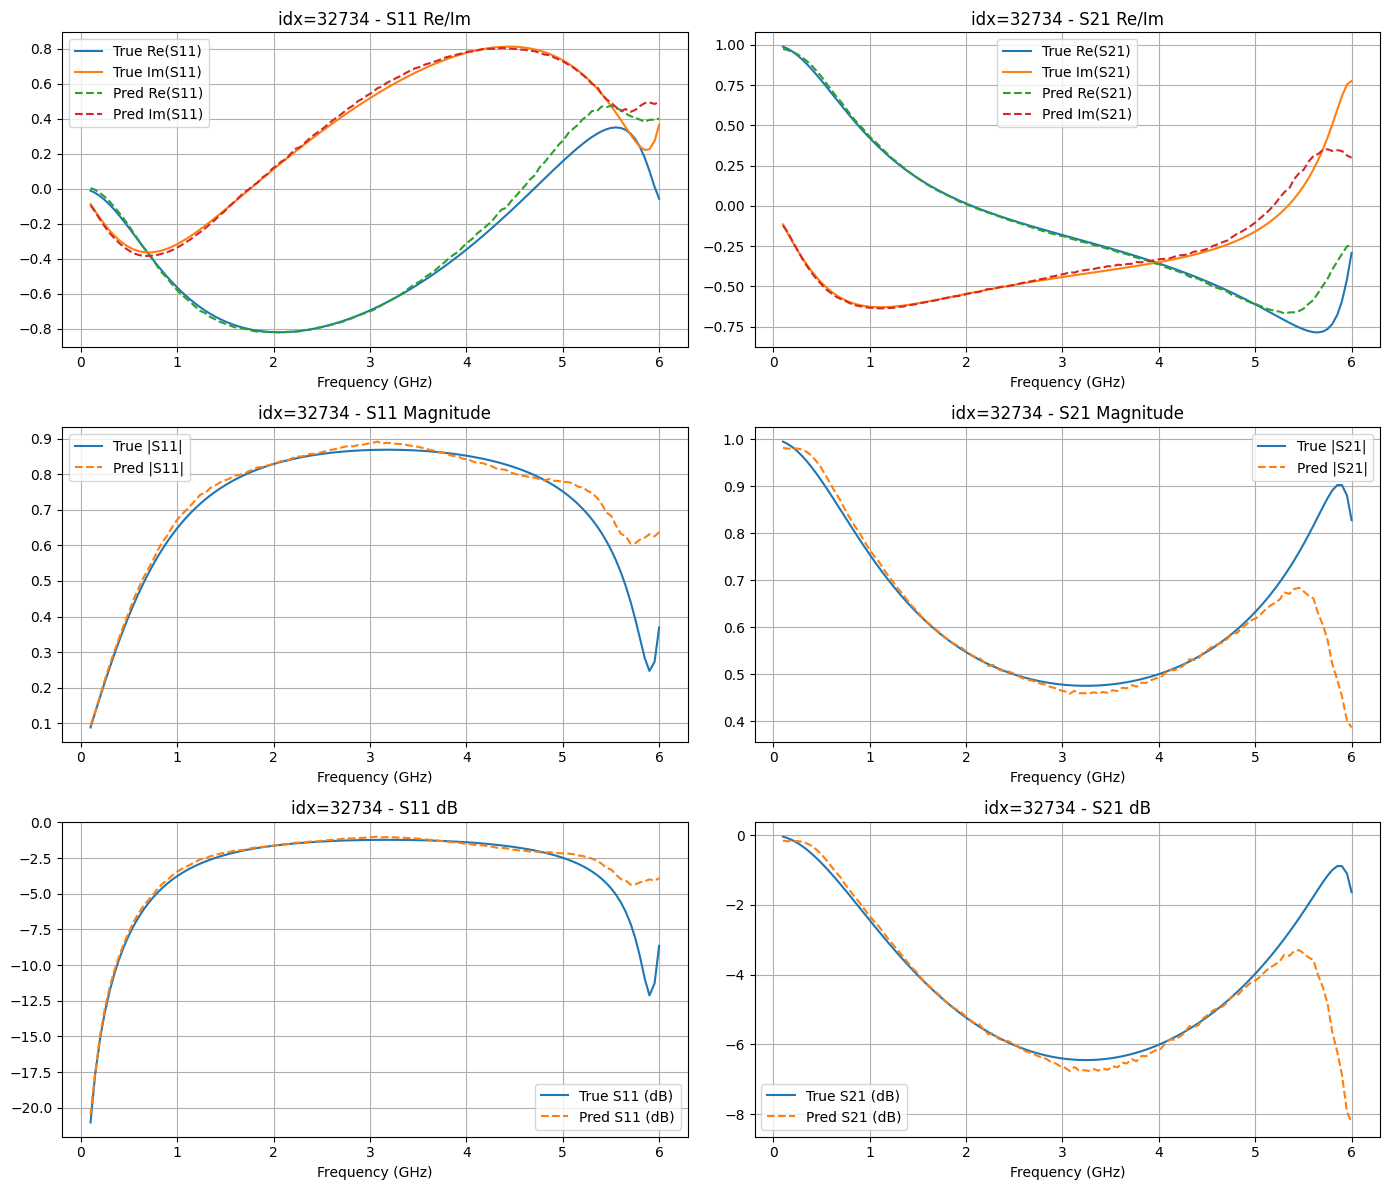

sample_index = 32734
MAE S11 (dB) = 0.558554
MAE S21 (dB) = 0.493205
------------------------------------------------------------


In [33]:
plot_random_samples(
    model=model,
    pack=pack,
    val_indices=val_indices,
    train_indices=train_indices,
    n_samples=5,
    seed=42,
    from_val=True,
)